In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('display.max_columns', 1500)

In [4]:
df = pd.read_csv('../data/raw/Etch.csv')

In [5]:
epi_tool = df[df["Tool ID"] == 0].copy()

## Tool Parameters
Input 1 range: 1400-1000, aggression: 10
Input 2 range: 1-6, aggression: 12
Output range: 5-3

In [6]:
epi_tool.head(10)

,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed
0,Etch,0,2,452,511,122.607824,2.164260,2.814075,False
2,Etch,0,1,545,607,129.770439,2.145046,2.756466,False
3,Etch,0,2,748,811,139.993207,2.269361,2.665654,False
5,Etch,0,5,993,1056,150.744249,2.388804,2.566758,False
8,Etch,0,6,1056,1118,166.934808,2.440108,2.425378,False
9,Etch,0,1,1177,1237,183.387971,2.515092,2.276678,False
10,Etch,0,9,1271,1333,208.954735,2.695682,2.028366,False
11,Etch,0,6,1359,1417,223.251780,2.870790,1.868746,False
12,Etch,0,10,1472,1526,236.333234,3.055206,1.709802,False
13,Etch,0,11,1600,1662,250.681962,3.126256,1.561415,False


## Holistic View of Data

In [7]:
epi_tool.describe()

,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output
count,12775.0,12775.000000,1.277500e+04,1.277500e+04,12775.000000,12775.000000,12775.000000
mean,0.0,7799.614325,7.853312e+05,7.853912e+05,210.094811,2.843703,1.952731
std,0.0,4488.066369,4.544685e+05,4.544685e+05,60.828507,0.492544,0.624248
min,0.0,1.000000,4.520000e+02,5.110000e+02,100.176877,1.943124,0.454510
25%,0.0,3928.500000,3.953680e+05,3.954270e+05,157.649754,2.431591,1.426230
50%,0.0,7814.000000,7.835420e+05,7.836040e+05,209.569028,2.819640,1.993259
75%,0.0,11661.500000,1.179403e+06,1.179464e+06,261.487984,3.219910,2.498301
max,0.0,15600.000000,1.576696e+06,1.576753e+06,351.413792,4.402846,2.998358


The average of the inputs seem to be within the ranges of the tool.

## Univariate Distributions

Looking at Inputs first, ensuring monotonic drift:

Text(0, 0.5, 'Runs')

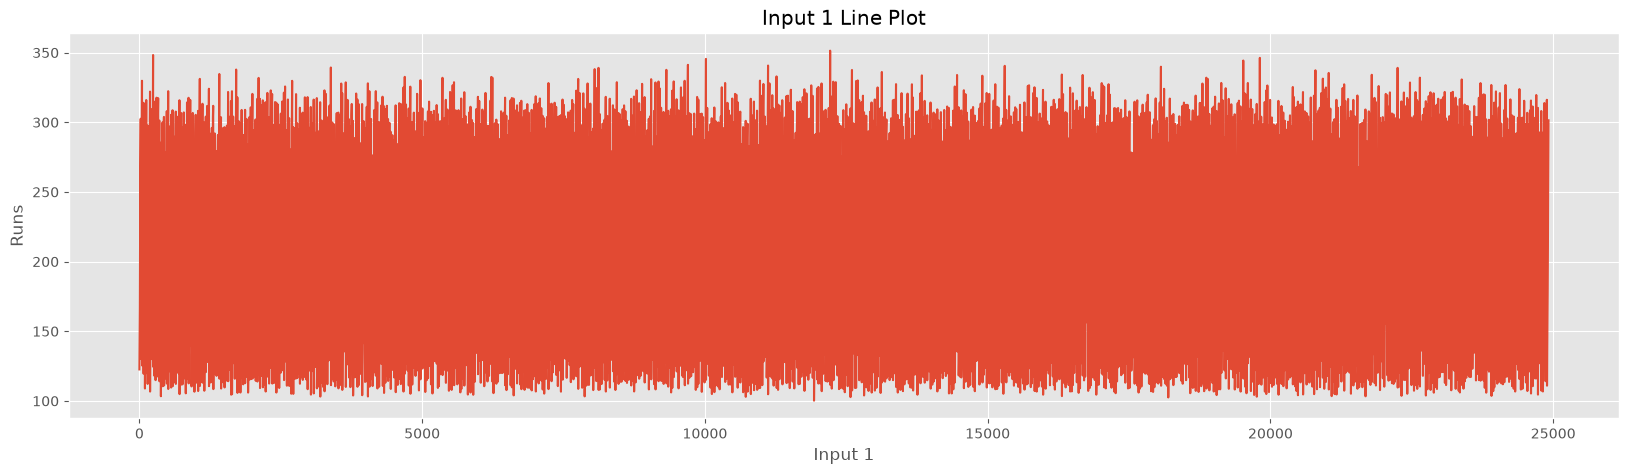

In [30]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 1'].plot(kind='line', title="Input 1 Line Plot")
line.set_xlabel('Input 1')
line.set_ylabel('Runs')

Text(0, 0.5, 'Runs')

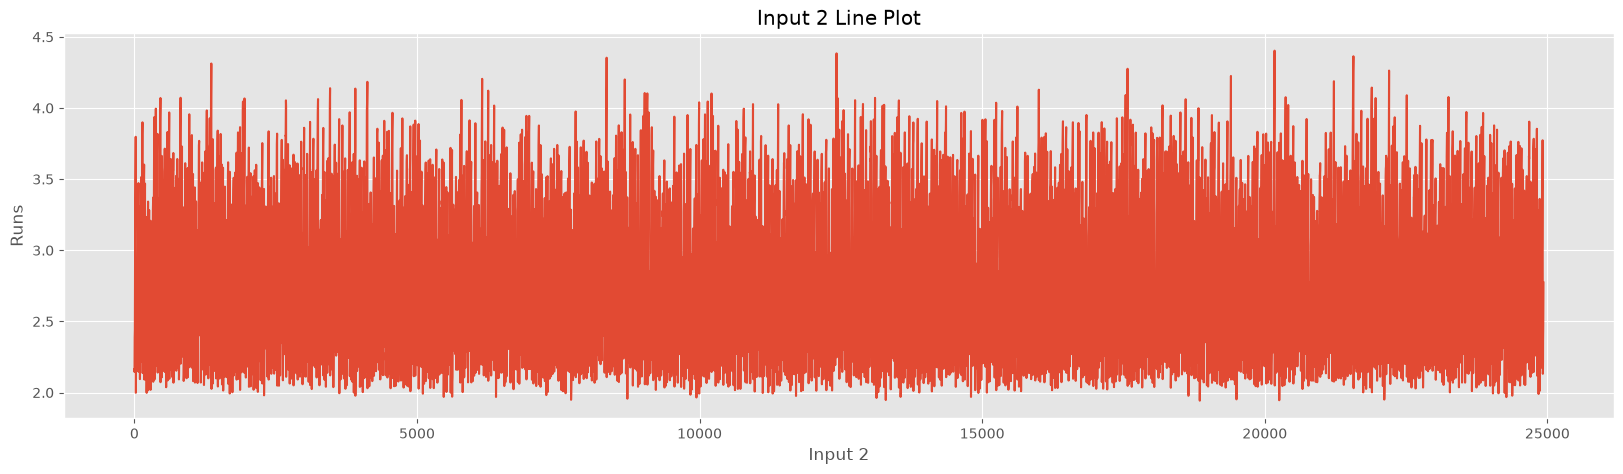

In [9]:
plt.figure(figsize=(20, 5))
line = epi_tool['Input 2'].plot(kind='line', title="Input 2 Line Plot")
line.set_xlabel('Input 2')
line.set_ylabel('Runs')

Both are showing what would be expected from degradation-driven inputs. Both show monotonic drift, although the noise in Input 2 seems to have a greater relative effect since Input 2 is much smaller in terms of magnitude.

Now an analysis of output

Text(0, 0.5, 'Runs')

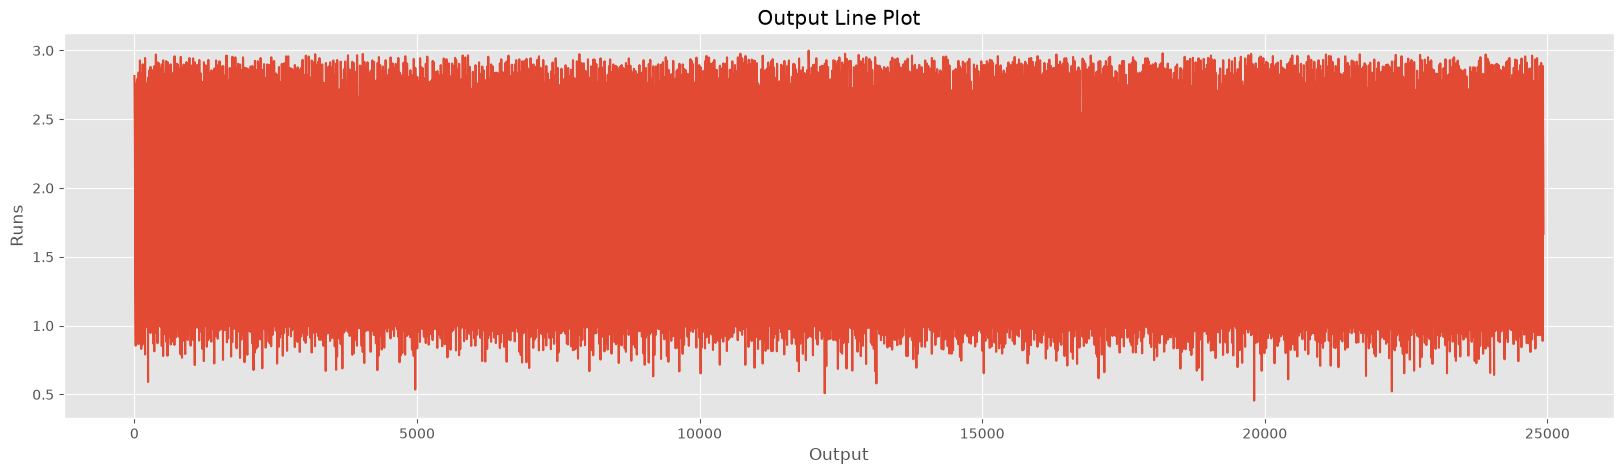

In [10]:
plt.figure(figsize=(20, 5))
line = epi_tool['Output'].plot(kind='line', title="Output Line Plot")
line.set_xlabel('Output')
line.set_ylabel('Runs')

<Axes: >

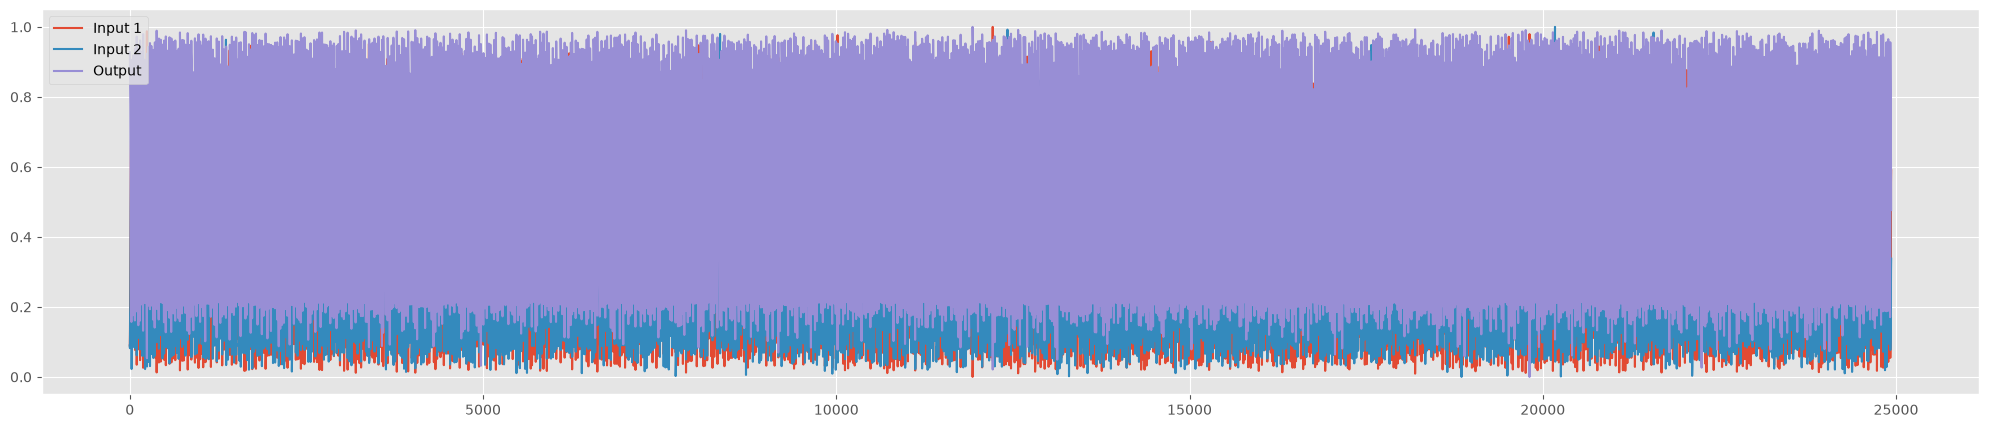

In [11]:
df_norm = (epi_tool[['Input 1', 'Input 2', 'Output']] - epi_tool[['Input 1', 'Input 2', 'Output']].min()) / \
          (epi_tool[['Input 1', 'Input 2', 'Output']].max() - epi_tool[['Input 1', 'Input 2', 'Output']].min())
df_norm.plot(kind='line',figsize=(25, 5))


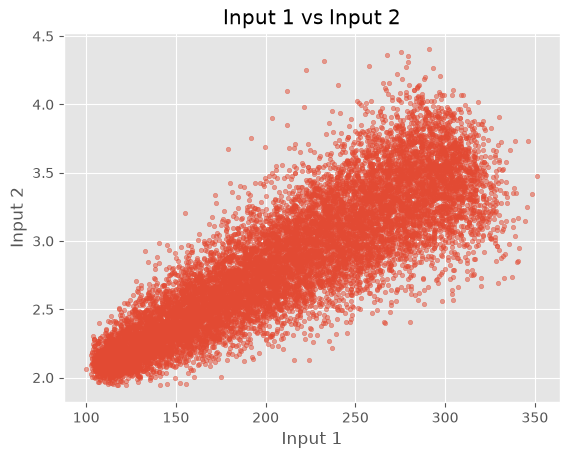

In [12]:
plt.scatter(epi_tool['Input 1'], epi_tool['Input 2'], alpha=0.5, s=10)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Input 1 vs Input 2')
plt.show()

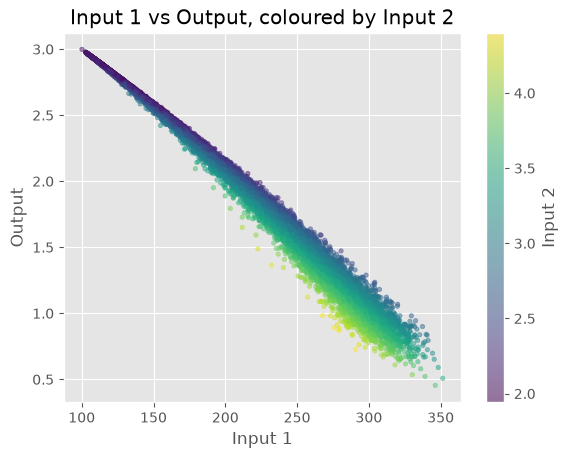

In [13]:
scatter = plt.scatter(epi_tool['Input 1'], epi_tool['Output'], c=epi_tool['Input 2'], alpha=0.5, s=10, cmap='viridis')
plt.xlabel('Input 1')
plt.ylabel('Output')
plt.colorbar(scatter, label='Input 2')
plt.title('Input 1 vs Output, coloured by Input 2')
plt.show()

In [14]:
epi_tool[['Input 1', 'Input 2', 'Output']].corr()

,Input 1,Input 2,Output
Input 1,1.000000,0.864608,-0.994020
Input 2,0.864608,1.000000,-0.905601
Output,-0.994020,-0.905601,1.000000


In [15]:
epi_tool['Input 2'].pow(2).corr(epi_tool['Output'])

np.float64(-0.8952179310820008)

As expected, Input 1 has a strong linear relationship with Output. Within the formula, Input 1 has a direct linear term in the formula used. Surprisingly, Input 2 also has a strong pairwise correlation (as input 2 is a non linear term in the equation),  potentially explained by Input 2 having a much narrower range, so its quadratic contribution does not have enough room to show its non-linearity. A look into the pearson correlation between Input 2 squared and output shows near enough the same value, confirming that the range is too narrow to see meaningful non-linear trends.

## Calculating RUL and observing individual variable effects on RUL

In [28]:
epi_tool["Shifted"] = epi_tool["Failed"].shift(periods=1, fill_value= False)
epi_tool["Cycle Group"] = epi_tool["Shifted"].cumsum()
epi_tool["Forward"] = epi_tool.groupby(["Cycle Group"]).cumcount()
epi_tool["Cycle Size"] = epi_tool.groupby("Cycle Group")["Failed"].transform("size")
epi_tool["RUL"] = epi_tool["Cycle Size"] - epi_tool["Forward"] - 1
epi_tool = epi_tool.drop(columns=['Shifted','Cycle Size','Forward'])
last_cycle = epi_tool["Cycle Group"].max()
last_cycle_rows = epi_tool["Cycle Group"] == last_cycle #cycle group as a series of boolean values
last_cycle_has_breach = epi_tool.loc[last_cycle_rows, 'Failed'].any()
if last_cycle_has_breach == False:
    epi_tool = epi_tool[~last_cycle_rows]



<Axes: xlabel='RUL', ylabel='Input 1'>

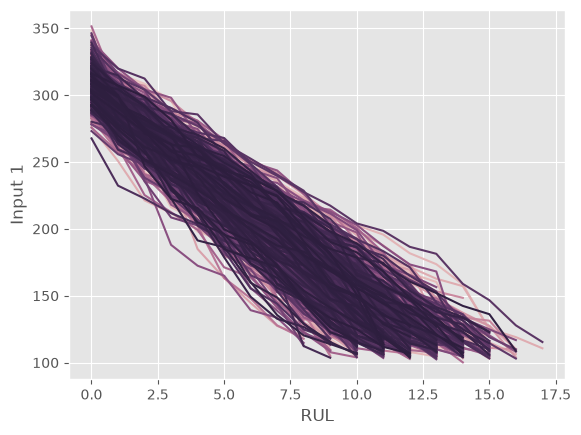

In [17]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Input 2'>

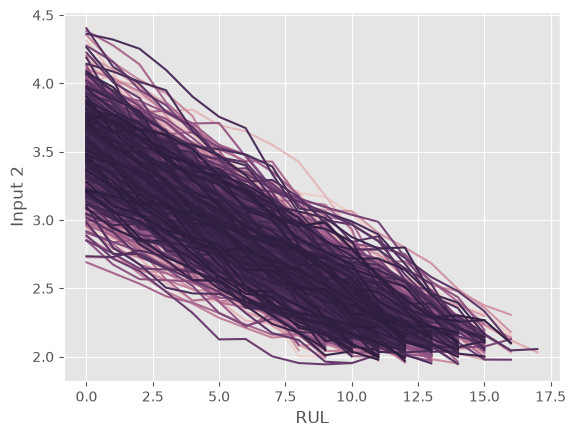

In [18]:
sns.lineplot(data=epi_tool, x="RUL", y="Input 2", hue="Cycle Group", legend = False)

In [19]:
epi_tool["Rolling Mean 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(5).mean().reset_index(level=0,drop=True)
epi_tool["Rolling Mean 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(5).mean().reset_index(level=0,drop=True)


<Axes: xlabel='RUL', ylabel='Rolling Mean 1'>

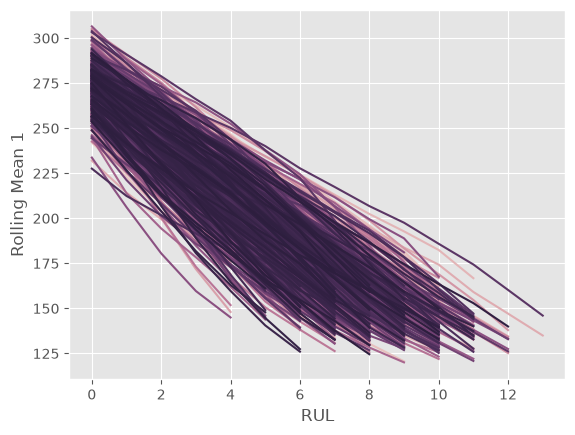

In [20]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Mean 2'>

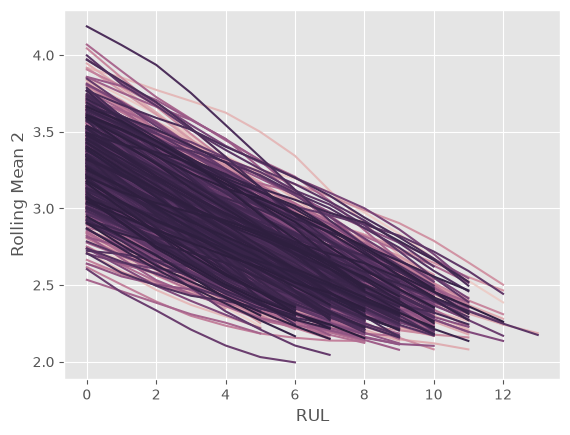

In [21]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Mean 2", hue="Cycle Group", legend = False)

Rolling means have smoothed out the cycles, but no major changes compared to raw values

<Axes: xlabel='RUL', ylabel='Rolling Std 1'>

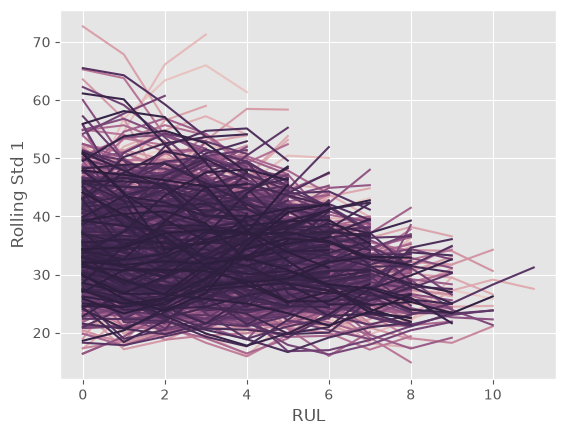

In [22]:
epi_tool["Rolling Std 1"] = epi_tool.groupby("Cycle Group")["Input 1"].rolling(7).std().reset_index(level=0,drop=True)
epi_tool["Rolling Std 2"] = epi_tool.groupby("Cycle Group")["Input 2"].rolling(7).std().reset_index(level=0,drop=True)
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 2'>

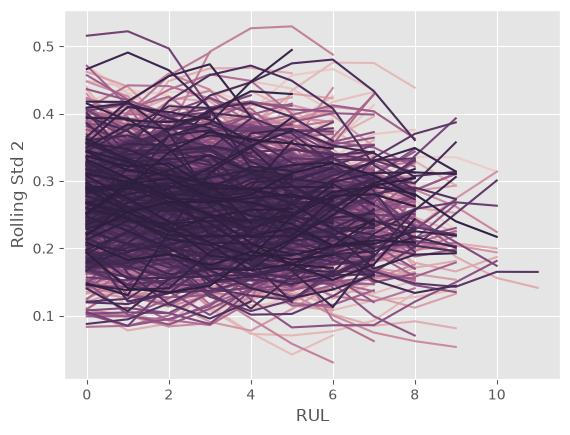

In [23]:
sns.lineplot(data=epi_tool, x="RUL", y="Rolling Std 2", hue="Cycle Group", legend = False)

In [24]:
n = 5
epi_tool["Shift1"] = epi_tool.groupby("Cycle Group")["Rolling Mean 1"].shift(n)
epi_tool["RoC1"] = epi_tool["Rolling Mean 1"] - epi_tool["Shift1"]

epi_tool["Shift2"] = epi_tool.groupby("Cycle Group")["Rolling Mean 2"].shift(n)
epi_tool["RoC2"] = epi_tool["Rolling Mean 2"] - epi_tool["Shift2"]

<Axes: xlabel='RUL', ylabel='RoC1'>

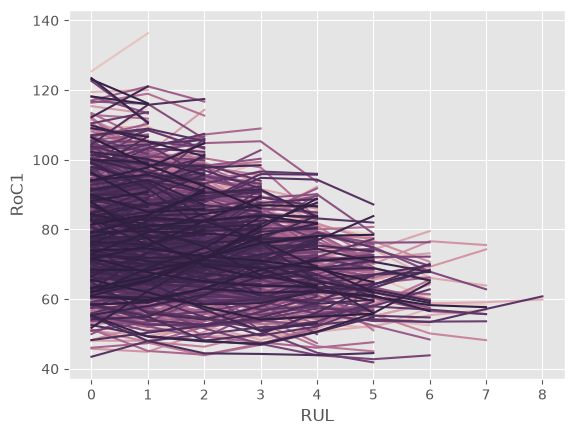

In [25]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='RoC2'>

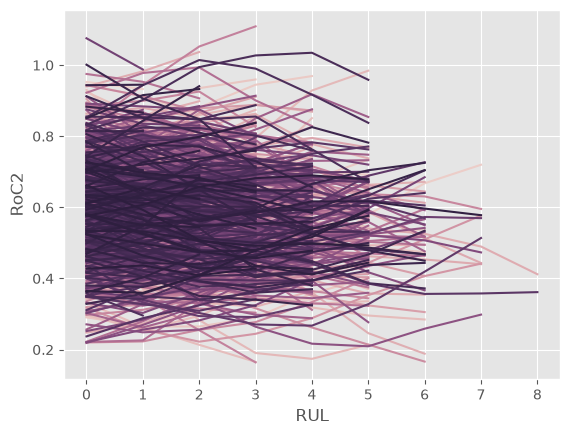

In [26]:
sns.lineplot(data=epi_tool, x="RUL", y="RoC2", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Output'>

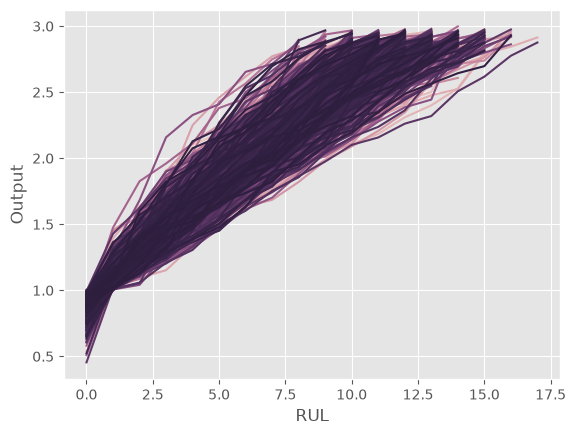

In [27]:
sns.lineplot(data=epi_tool, x="RUL", y="Output", hue="Cycle Group", legend=False)